# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Matthew Burgos

**ID**: mb2557

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [4]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/hw2-matt-b`


In [5]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

<img src="figures/Q1.png" alt="">

Figure 1: System diagram between global mean temperature, atmospheric CO2 concentrations, and ocean CO2 concentrations.

As atmopheric CO2 increases, global mean teamperature also increases due to climate change and the increase of the greenhouse effect, which increases that amount of solar radiation that stays within the atmosphere.

As atmospheric CO2 increases, ocean CO2 also increases because of Henry's law, which states that the amount of CO2 in liquid is propotional to its amount in the gas directly above the liquid. (Source: https://en.wikipedia.org/wiki/Henry%27s_law)

As global mean temperature increases, ocean CO2 decreases because of water solubility. Increased temperature leads to decreased solubility of CO2, decreasing the proportion of CO2 that is stored in the ocean. (Source: https://www.engineeringtoolbox.com/gases-solubility-water-d_1148.html)

This means that there is a dampening feedback between temperature and the ocean carbon cycle (disregarding atmopheric carbon). Increased temperature dampens concentration of oceanic CO2. Considering the three parts as a whole, there are both dampening and amplifying aspects. Increasing atmospheric CO2 increases ocean CO2, while increasing temperature decreases ocean CO2. Henry's law and water solubility push the ocean CO2 concentration in different directions. Overall, however, data shows that oceanic CO2 concentration is increasing over time, suggesting that the impact of Henry's law is more significant (Source: https://ocean.si.edu/conservation/acidification/ocean-acidification-graph).

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 


<img src="figures/river_diagram.png" alt="Schematic of the river system in Problem 2">

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

<img src="figures/Q2_a.png" alt="">

Figure 2: Systems diagram showing relevant control volumes and flows for problem 2

I decided to have two control volumes to account for the two different wastewater discharges. It is important to have two control volumes because each control volume has different initial conditions. Now I can account for the decay that happens in between the first and second wastewater discharge. If I combined both discharges into one control volume, it would be difficult because I would have to account for decay, deposition, and a new discharge all in one.

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

Changes in concentration with respect to distance depend only on atmopheric deposition and decay. The flows will determine initial conditions. 

$$
\frac{dC}{dx}=deposition - decay\\[12pt]

\frac{dC}{dx}=\frac{54kg}{km*day}*\frac{1 day}{(250,000+40,000)m^3}-\frac{0.36}{day}*\frac{Ckg}{m^3}*\frac{1 day}{10 km}\\[12pt]

\frac{dC}{dx}=\frac{54kg}{(290,000)km*m^3}-\frac{(0.036C)kg}{km*m^3}\\[12pt]

\frac{dC}{dx}=\frac{54}{290,000}-0.036C\\[12pt]

Let\enspace A=\frac{54}{290,000}, B=0.036 \\[12pt]

\frac{dC}{dx}=A-BC\\[12pt]

dC=(A-BC)dx\\[12pt]

dC=(\frac{A}{B}-C)Bdx\\[12pt]

\frac{1}{\frac{A}{B}-C}dC=Bdx\\[12pt]

\int\frac{1}{\frac{A}{B}-C}dC=\int Bdx\\[12pt]

-ln\left| \frac{A}{B}-C \right|=Bx+D\\[12pt]

\frac{A}{B}-C=e^{-Bx+D} \\[12pt]

\frac{A}{B}-C=De^{-Bx} \\[12pt]

C=\frac{A}{B}-De^{-Bx} \\[12pt]

C=\frac{\frac{54}{290,000}}{0.036}-De^{-0.036x} \\[12pt]

C=\frac{\frac{54}{290,000}}{0.036}-De^{-0.036x} \\[12pt]

C=\frac{3}{580}-De^{-0.036x}, C(0)=concentration\enspace after\enspace mixing\\[12pt]

C=\frac{3}{580}-De^{-0.036x}, C(0)=\frac{250,000*0.0005+40,000*0.009}{250,000+40,000}\\[12pt]

C=\frac{3}{580}-De^{-0.036x}, C(0)=\frac{485}{290,000}\\[12pt]

\frac{485}{290,000}=\frac{3}{580}-De^{-0.036(0)}\\[12pt]

\frac{485}{290,000}-\frac{3}{580}=-De^{-0.036(0)}\\[12pt]

D=\frac{7}{2,000}\\[12pt]

C=\frac{3}{580}-\frac{7}{2,000}e^{-0.036x} \enspace if \enspace x<15\enspace km \\[12pt]

$$

For distances greater than 15, the initial condition and flow rate changes because of the new discharge.

$$
C(x\to 15)=\frac{3}{580}-\frac{7}{2,000}e^{-0.036(15)} \\[12pt]

C(x\to 15)=0.00313 \\[12pt] 

C(15)=\frac{0.00313*290,000+0.007*60,000}{290,000+60,000}\\[12pt]

C(15)=0.003796\\[12pt] 

\frac{dC}{dx}=\frac{54}{290,000+60,000}-0.036C\\[12pt]

\frac{dC}{dx}=\frac{54}{350,000}-0.036C\\[12pt]

C=\frac{3}{700}-De^{-0.036x}, C(15)=0.003796 \\[12pt]

0.003796=\frac{3}{700}-De^{-0.036(15)} \\[12pt]

0.00048997=-De^{-0.036(15)} \\[12pt]

D=0.0008408 \\[12pt]

C=\frac{3}{700}-(0.0008408)e^{-0.036x} \enspace if \enspace x\ge15\enspace km \\
$$





Result: 
$$
C(x)=\frac{3}{580}-\frac{7}{2,000}e^{-0.036x} \enspace if \enspace x<15\enspace km \\[12pt]

C(x)=\frac{3}{700}-(0.0008408)e^{-0.036x} \enspace if \enspace x\ge15\enspace km \\
$$

#### Problem 2.3 

Determine if the system in compliance with a regulatory limit of $2.3\ \text{kg}/(1000\text{m}^3)$. You can do this analytically or computationally.

0.005107880464297635

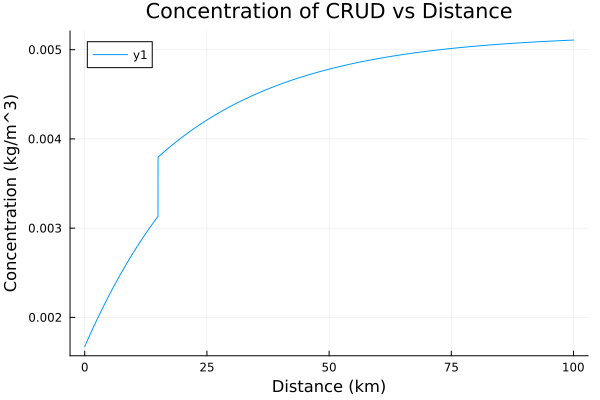

In [260]:
# Numerical Solution using Forward Euler

iterations = 10000
concentrations = zeros(iterations)
times = range(0, stop=max_dist, length=iterations)
max_dist = 100 # maximum number of km

# first initial condition
concentrations[1] = 485/290000

# only loop until 15 km
for i in 1:1499
    dcdt = 54/290000 - 0.036*concentrations[i]
    concentrations[i+1] = concentrations[i] + times[2]*dcdt
end

# second initial condition
concentrations[1501] = (concentrations[1500]*290000+0.007*60000)/(290000+60000)

# loop for rest of distance
for i in 1501:iterations-1
    dcdt = 54/290000 - 0.036*concentrations[i]
    concentrations[i+1] = concentrations[i] + times[2]*dcdt
end

print(maximum(concentrations))

plot(times, concentrations, title="Concentration of CRUD vs Distance", xlabel="Distance (km)", ylabel="Concentration (kg/m^3)")

Figure 3: Numerical Forward Euler Solution plot showing concentration of CRUD vs distance for problem 2

The system is not in compliance with the regulatory limit of 0.0023 kg/m^3. The maximum concentration is above 0.0051 kg/m^3, and the concentration exceeds 0.0023 kg/m^3 even before the second discharge as shown in the graph.

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

$$
C\frac{dT}{dt}=\frac{(1-\alpha)S}{4}-(A-BT) \\[12pt]

\frac{dT}{dt}=\frac{\frac{(1-\alpha)S}{4}-(A-BT)}{C} \\[12pt]

\frac{T(t+\Delta t)-T(t)}{\Delta t}=\frac{\frac{(1-\alpha)S}{4}-(A-BT(t))}{C} \\[12pt]

T(t+\Delta t)-T(t)=\Delta t*\frac{\frac{(1-\alpha)S}{4}-(A-BT(t))}{C} \\[12pt]

T(t+\Delta t)=T(t)+ \Delta t*\frac{\frac{(1-\alpha)S}{4}-(A-BT(t))}{C} \\[12pt]

T(t+1)=T(t)*\frac{\frac{(1-\alpha)S}{4}-(A-BT(t))}{C} \\[12pt]

T(t+1)=T(t)*\frac{\frac{(1-\alpha)S}{4}-A+BT(t)}{C}
$$

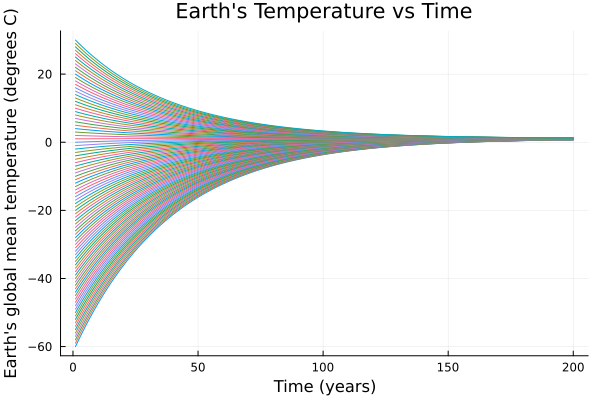

In [ ]:
# Plot the forward Euler integration

years = 200
times = collect(1:years)

# Given constants
C = 51 #J/(m^2 * deg C)
alpha = 0.3
S_neoproteorozoic = 1272 #W/m^2
B = -1.3 #W/(m^2 * deg C)
A = 221.2 #W/m^2

# Function to return an array of times using forward euler
function getTemps(initial_T)
    T = zeros(years)
    T[1] = initial_T
    for i in 1:years-1
        dTdt = ((1-alpha)*S_neoproteorozoic/4 - (A-B*T[i]))/C
        T[i+1] = T[i] + dTdt
    end
    return T
end

# Plot results for initial times ranging -60 to 30 degrees C
p = plot(xlabel="Time (years)", ylabel="Earth's global mean temperature (degrees C)", title="Earth's Temperature vs Time")
for i in -60:30
    plot!(p, times, getTemps(i), legend=false)
end
p

Figure 4: Earth's temperature over time using forward Euler numerical integration assuming Neoproteorozoic solar constant and starting temperatures -60 to 30.

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

-47.42833826546848

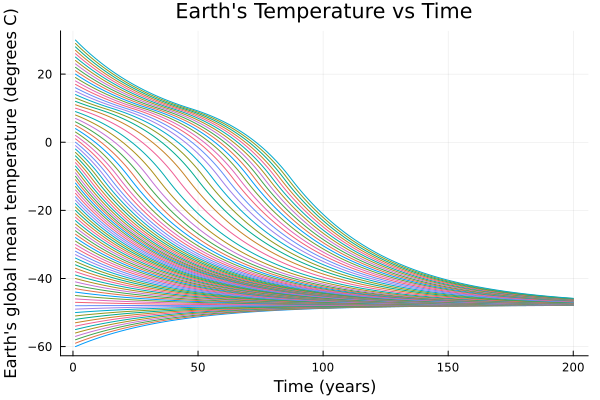

In [60]:
# Plot the forward Euler integration

years = 200
times = collect(1:years)

# Given constants
C = 51 #J/(m^2 * deg C)
alpha_i = 0.5
alpha_0 = 0.3
S_neoproteorozoic = 1272 #W/m^2
B = -1.3 #W/(m^2 * deg C)
A = 221.2 #W/m^2

# Function to return an array of times using forward euler
function getTemps(initial_T)
    T = zeros(years)
    T[1] = initial_T
    for i in 1:years-1

        # Adjust albedo based on temperature
        if T[i] <= -10
            alpha = alpha_i
        end
        if -10 <= T[i] <= 10
            alpha = alpha_i+(alpha_0-alpha_i)*(T[i]+10)/20
        end
        if T[i] >= 10
            alpha = alpha_0
        end

        # Forward Euler
        dTdt = ((1-alpha)*S_neoproteorozoic/4 - (A-B*T[i]))/C
        T[i+1] = T[i] + dTdt
    end

    return T
end

# Plot results and get final temp for initial times ranging -60 to 30 degrees C
final_values = zeros(91)
p = plot(xlabel="Time (years)", ylabel="Earth's global mean temperature (degrees C)", title="Earth's Temperature vs Time")
for i in -60:30
    final_values[i+61] = getTemps(i)[years]
    plot!(p, times, getTemps(i), legend=false)
end

# Print the mean final value to get equilibrium
print(sum(final_values)/length(final_values))

p

Figure 5: Earth's temperature over time using forward Euler numerical integration adjusting albedo based on temperature. Neoproteorozoic solar radiation is assumed.

There is one stable equilibrium for all initial temperatures at around -47.4 degrees C. This is shown by the graph because all paths converge to the same temperature. It can be described as stable because the temperture will converge to this equilibrium despite having displacements away from the equilibrium.

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

-38.502603062986715 14.027742607986971

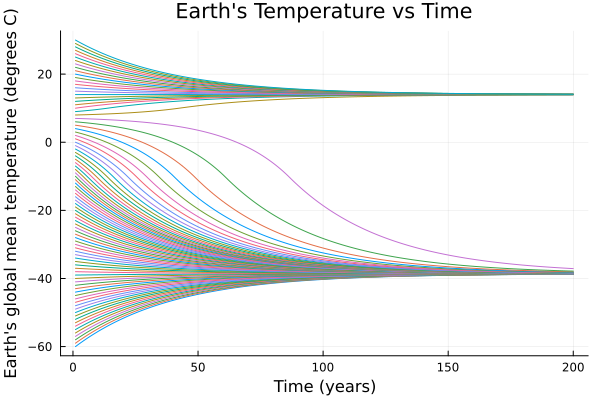

In [78]:
# Plot the forward Euler integration

years = 200
times = collect(1:years)

# Given constants
C = 51 #J/(m^2 * deg C)
alpha_i = 0.5
alpha_0 = 0.3
S_current = 1368 #W/m^2
B = -1.3 #W/(m^2 * deg C)
A = 221.2 #W/m^2

# Function to return an array of times using forward euler
function getTemps(initial_T)
    T = zeros(years)
    T[1] = initial_T
    for i in 1:years-1

        # Adjust albedo based on temperature
        if T[i] <= -10
            alpha = alpha_i
        end
        if -10 <= T[i] <= 10
            alpha = alpha_i+(alpha_0-alpha_i)*(T[i]+10)/20
        end
        if T[i] >= 10
            alpha = alpha_0
        end

        # Forward Euler
        dTdt = ((1-alpha)*S_current/4 - (A-B*T[i]))/C
        T[i+1] = T[i] + dTdt
    end

    return T
end

# Plot results and get final temp for initial times ranging -60 to 30 degrees C
final_values = zeros(91)
p = plot(xlabel="Time (years)", ylabel="Earth's global mean temperature (degrees C)", title="Earth's Temperature vs Time")
for i in -60:30
    final_values[i+61] = getTemps(i)[years]
    plot!(p, times, getTemps(i), legend=false)
end

# Print the mean final value to get equilibrium
print(sum(final_values[1:68])/length(final_values[1:68]))
print(' ')
print(sum(final_values[69:91])/length(final_values[69:91]))

p

Figure 6: Earth's temperature over time using forward Euler numerical integration adjusting albedo based on temperature. Modern solar radiation is assumed.

The change in solar radiation is enough to warm the planet to 14 degrees C. As shown in the graph, now there are two stable equilibium. One is at around -38.5 degrees C and the other is around 14.0 degrees C. Based on the model, if Earth's global mean temperature were to be above approximately 8 degrees C, then the temperture would increase over time to 14 degrees C.

## References

List any external references consulted, including classmates.

Zeros() function in Julia: https://www.jlhub.com/julia/manual/en/function/zeros

Plots in Julia: https://docs.juliaplots.org/stable/

Latex editor: https://latexeditor.lagrida.com/

Canva to draw diagrams: https://www.canva.com/
